# Import packages

In [1]:
import numpy as np
from juliacall import Main as jl
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'retina'

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
jl.seval('import Pkg; Pkg.status()')

Status `/opt/anaconda3/envs/sim/julia_env/Project.toml`
  [6099a3de] PythonCall v0.9.28
  [7bf6e793] SciBmad v0.1.5
  [458c3c95] OpenSSL_jll v3.5.4+0


In [3]:
jl.seval('using SciBmad')

# Try make a simple ring

In [4]:
## Make a FODO cell requiring that
# qf.Kn1 = -qd.Kn1 
# and
# sf.Kn2 = -sd.Kn2
# This is done using a "deferred expression"
# to form a "closure" of the variables we define:

K1 = 0.36
K2 = 0.1
hkick1 = 0.0
vkick1 = 0.0
hkick = 0.0
vkick = 0.0

qf = jl.Quadrupole(Kn1=jl.DefExpr(lambda : +K1), L=0.5)
sf = jl.Sextupole(Kn2=jl.DefExpr(lambda : +K2), L=0.2)

# can turn on correctors in the first FODO cell
cf1 = jl.HKicker(Kn0L=jl.DefExpr(lambda: -hkick1),L=0.)
cd1 = jl.VKicker(Ks0L=jl.DefExpr(lambda: -vkick1),L=0.)

cfcorr = jl.HKicker(Kn0L=jl.DefExpr(lambda: -hkick),L=0.)
bpm1 = jl.Marker(name="BPM")
d  = jl.Drift(L=0.6)
b  = jl.SBend(L=6.0, angle=np.pi/20)
qd = jl.Quadrupole(Kn1=jl.DefExpr(lambda : -K1), L=0.5)
sd = jl.Sextupole(Kn2=jl.DefExpr(lambda : -K2), L=0.2)
cdcorr = jl.VKicker(Ks0L=jl.DefExpr(lambda: -vkick),L=0.)
bpm2 = jl.Marker(name="BPM")


fodo_line1 = [qf, bpm1, sf, cf1, bpm1, d, b, d, qd, bpm2, sd, cd1, bpm2, d, b, d]
fodo_line = [qf, bpm1, sf, cfcorr, bpm1, d, b, d, qd, bpm2, sd, cdcorr, bpm2, d, b, d]
ring_line = jl.vcat(fodo_line1,jl.repeat(fodo_line,19))
simple_ring = jl.Beamline(ring_line, species_ref=jl.Species("proton"), E_ref=1e9)

# Calculate Twiss of the ring

In [5]:
t = jl.twiss(simple_ring)

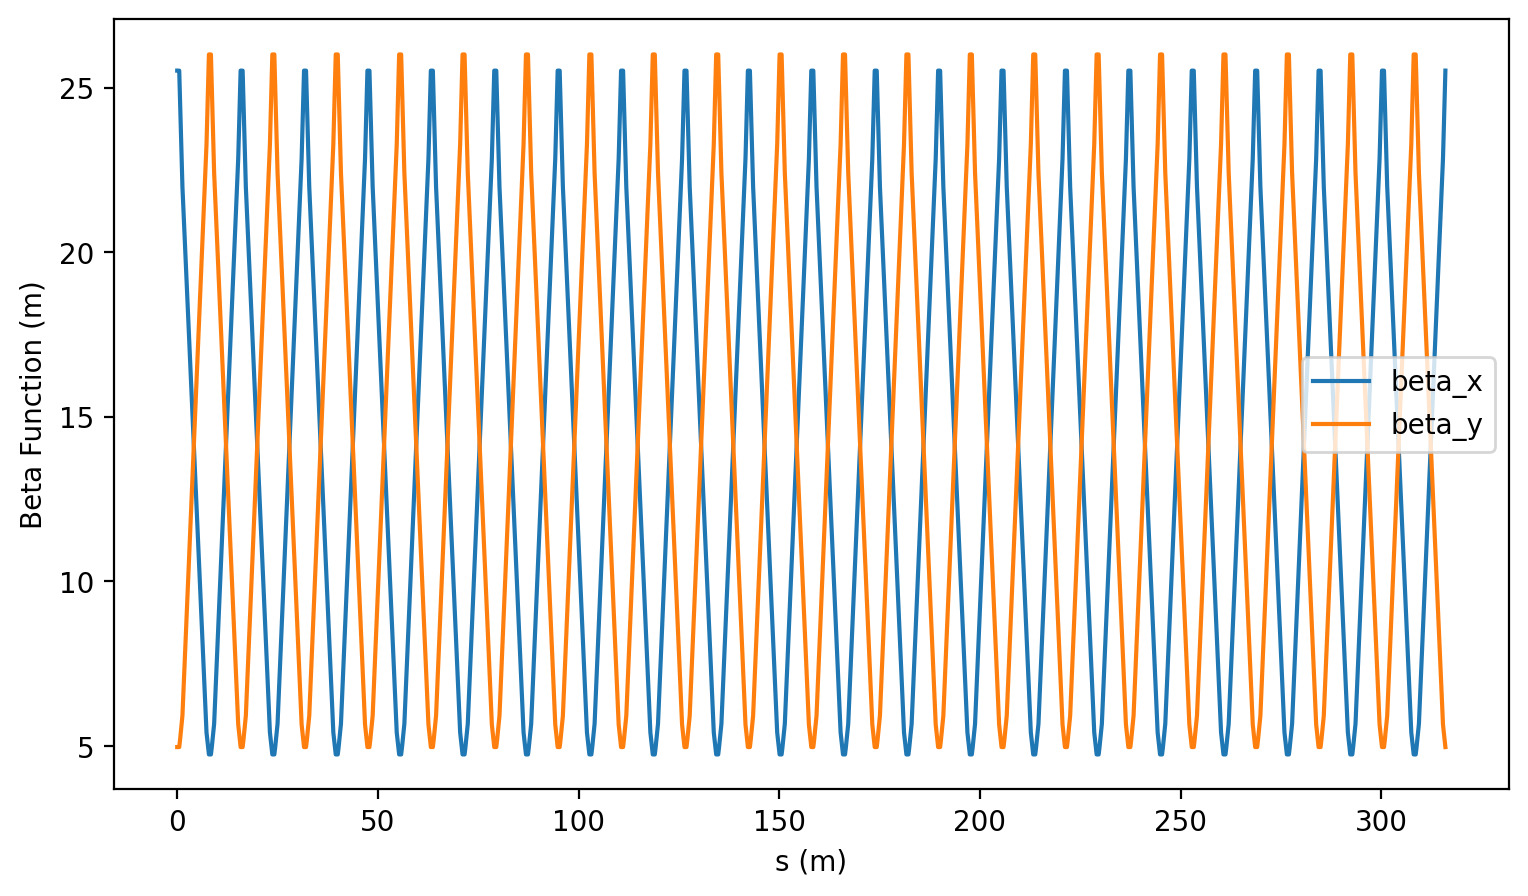

In [6]:
plt.figure(figsize=(9,5))
plt.plot(t.s, t.beta_1, label='beta_x')
plt.plot(t.s, t.beta_2, label='beta_y')
plt.xlabel('s (m)')
plt.ylabel('Beta Function (m)')
plt.legend();

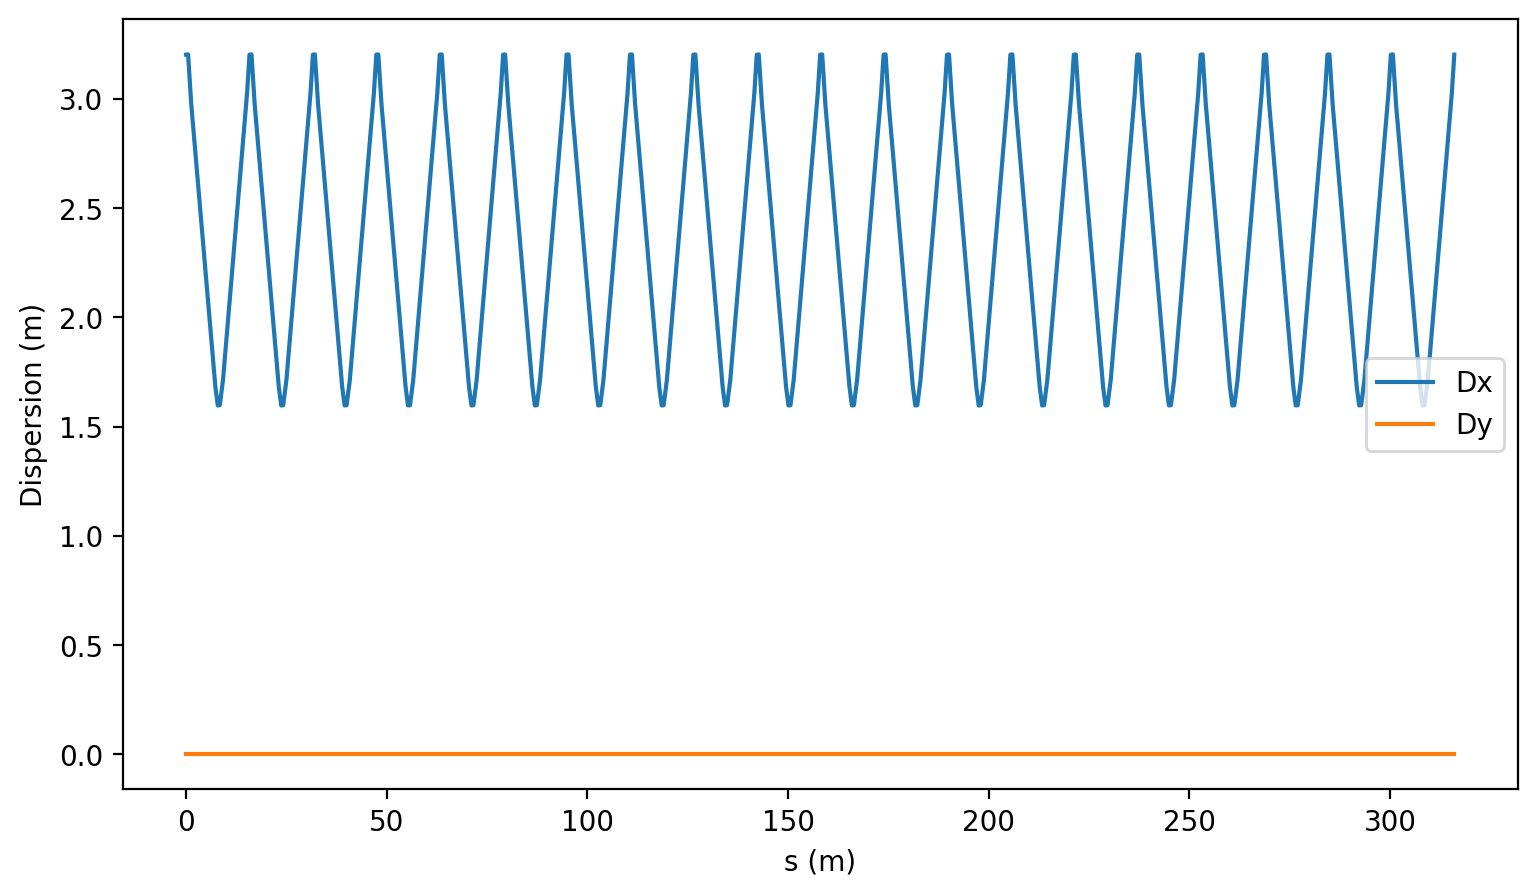

In [7]:
plt.figure(figsize=(9,5))
plt.plot(t.s, t.eta_1, label='Dx')
plt.plot(t.s, t.eta_2, label='Dy')
plt.xlabel('s (m)')
plt.ylabel('Dispersion (m)')
plt.legend();

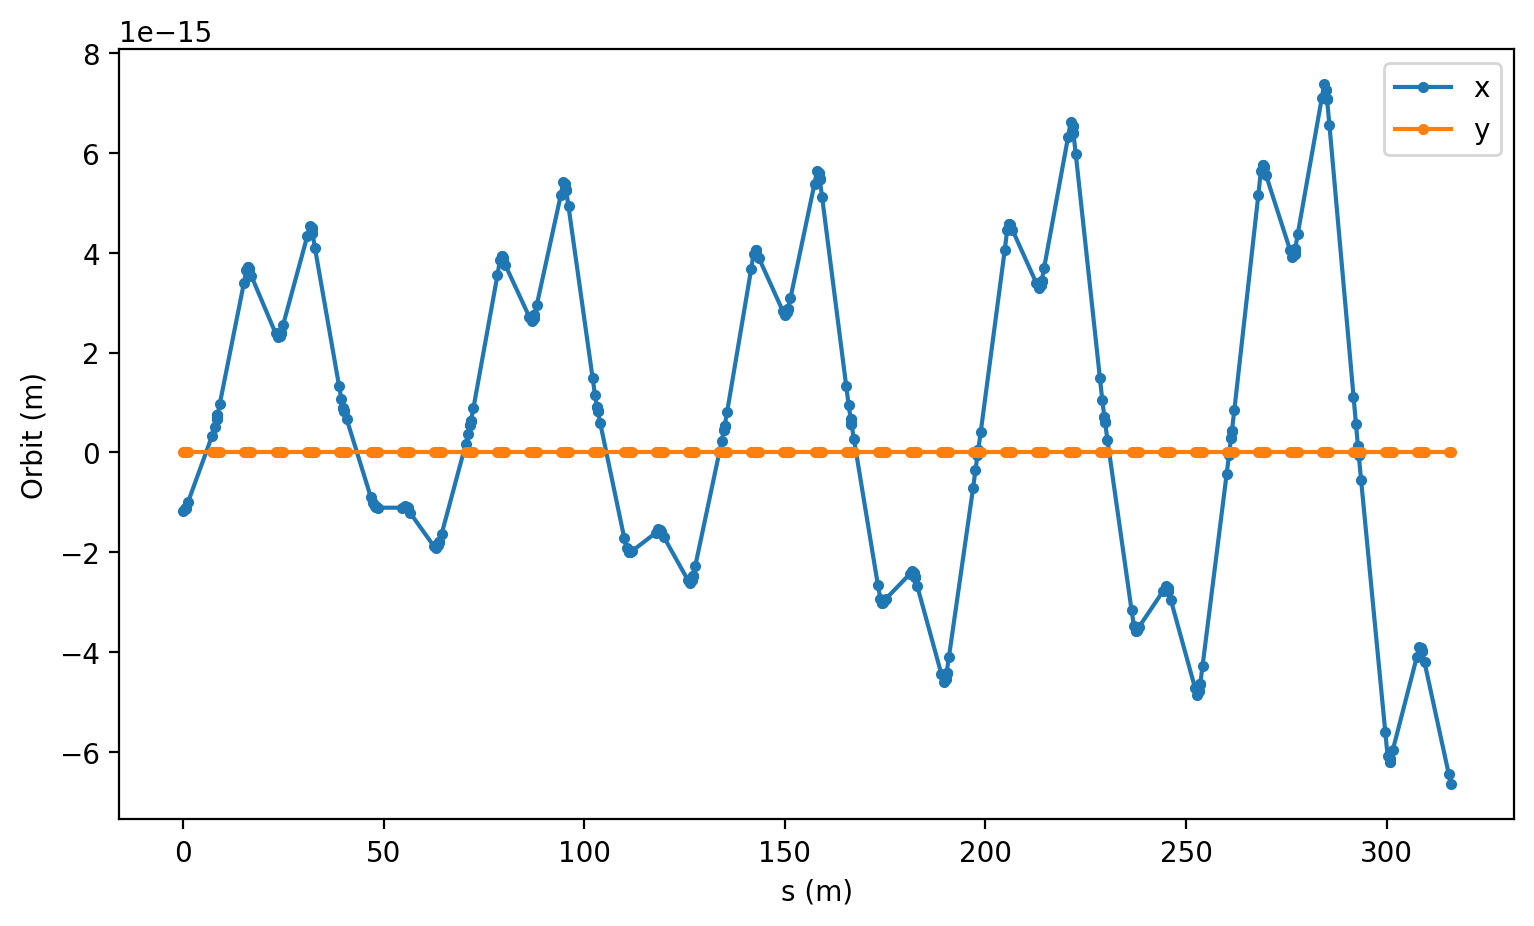

In [8]:
plt.figure(figsize=(9,5))
plt.plot(t.s,t.orbit_x,'.-',label='x')
plt.plot(t.s,t.orbit_y,'.-',label='y')
plt.xlabel('s (m)')
plt.ylabel('Orbit (m)')
plt.legend();

## Try turn on the first horizontal corrector

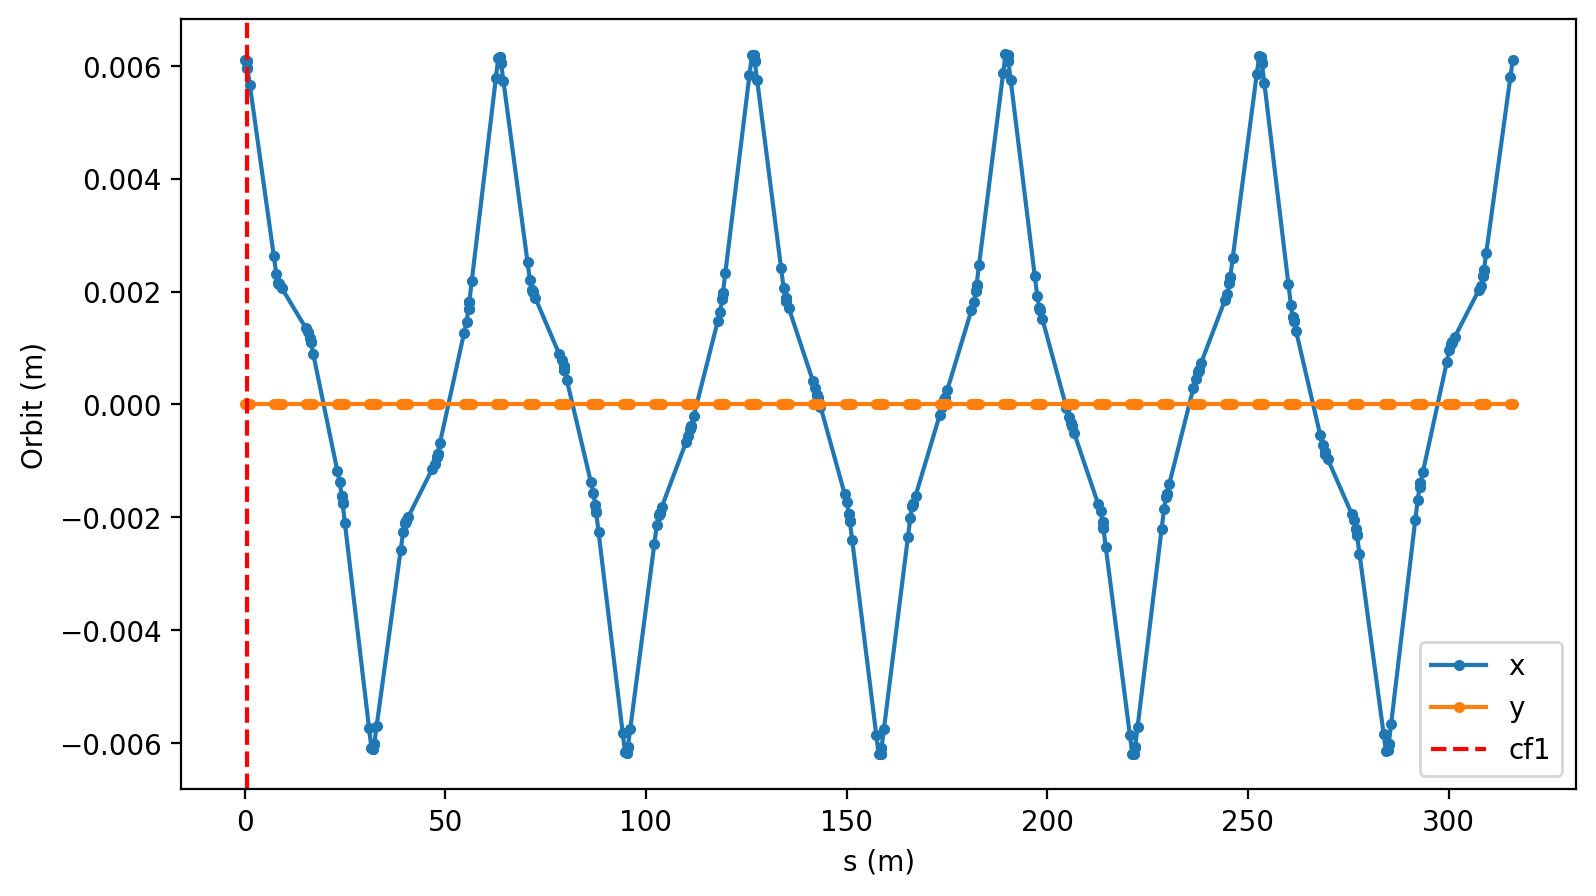

In [9]:
vkick1 = 0
hkick1 = 0.0001
t_hor = jl.twiss(simple_ring)
plt.figure(figsize=(9,5))
plt.plot(t_hor.s,t_hor.orbit_x,'.-',label='x')
plt.plot(t_hor.s,t_hor.orbit_y,'.-',label='y')
plt.axvline(simple_ring.line[3].s,color='r',linestyle='--',label='cf1')
plt.xlabel('s (m)')
plt.ylabel('Orbit (m)')
plt.legend();

## Now try turn on the first vertical corrector

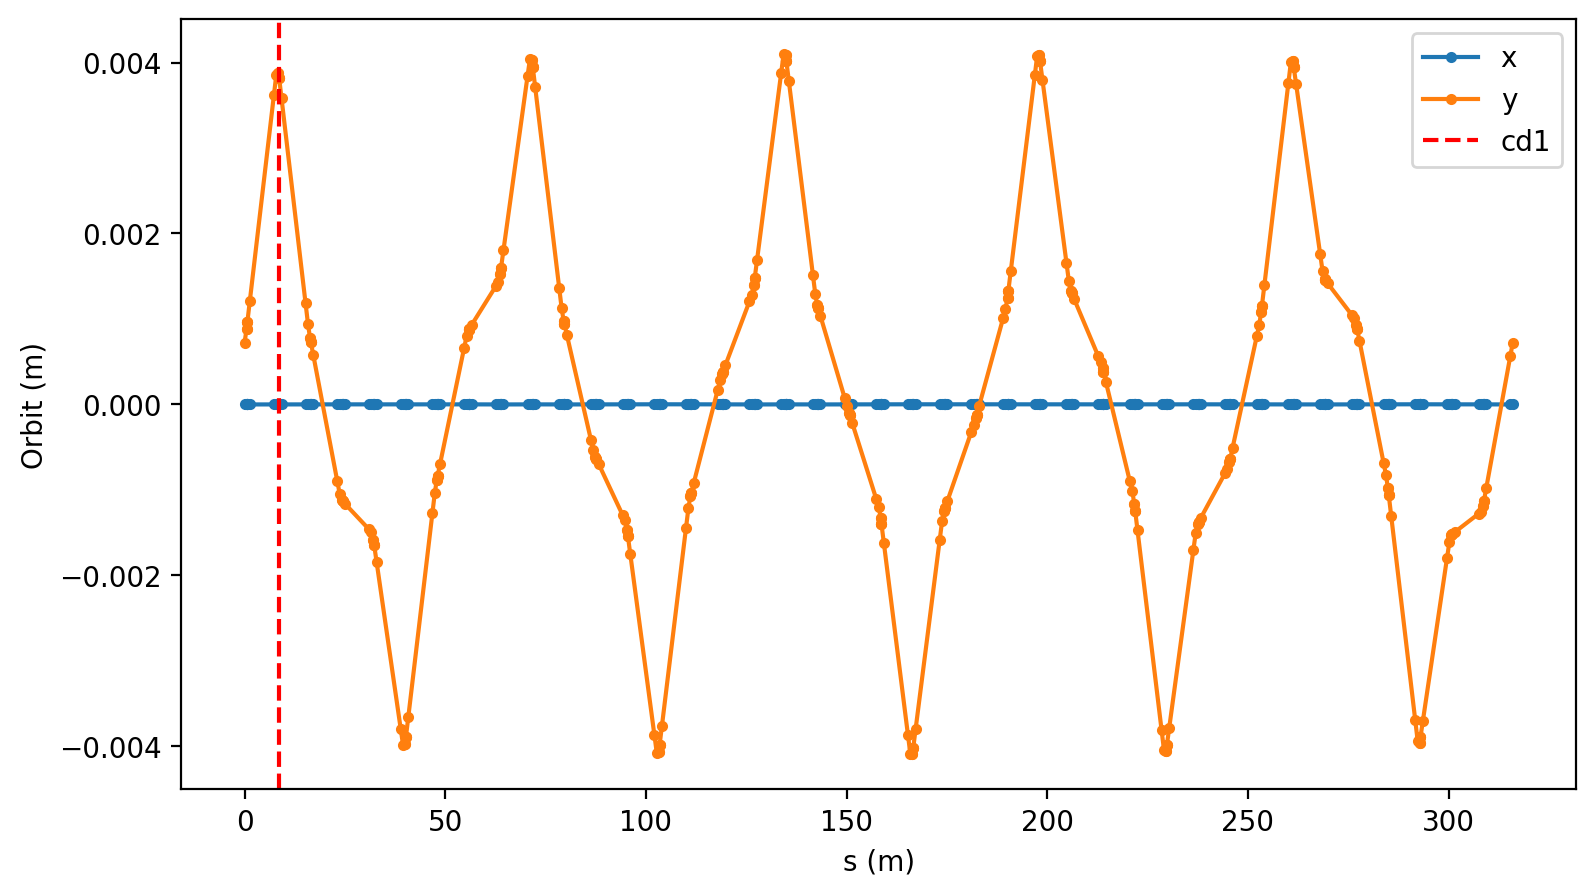

In [10]:
hkick1 = 0
vkick1 = 0.0001
t_ver = jl.twiss(simple_ring)
plt.figure(figsize=(9,5))
plt.plot(t_ver.s,t_ver.orbit_x,'.-',label='x')
plt.plot(t_ver.s,t_ver.orbit_y,'.-',label='y')
plt.axvline(simple_ring.line[11].s,color='r',linestyle='--',label='cd1')
plt.xlabel('s (m)')
plt.ylabel('Orbit (m)')
plt.legend();

# Base parameters

In [11]:
# --- Base parameters ---
D = jl.Descriptor(6,2,40,2) # 6 variables, 1st order, 40 parameters, 1st order

# quadreupole and sextupole strengths
K1 = 0.36
K2 = 0.1

# reference parameters for the ring
Ncell = 20
sp = jl.Species("proton")
energy = 1e9

# Define one FODO cell

In [12]:
def fodo_cell(Ncells=20, hkick_strength=0.0, vkick_strength=0.0):
    """
    Constructs a single FODO cell with configurable bending based on the number of cells.

    This function defines one periodic cell of a FODO-type lattice consisting of
    quadrupoles, sextupoles, dipoles, drifts, and beam position monitors (BPMs).
    The cell structure can optionally include horizontal and vertical kickers
    to introduce local orbit distortions. The total bending angle per cell is
    determined by the number of cells `Ncells`, so that a full ring can be formed
    when `Ncells` cells are concatenated.

    Parameters
    ----------
    Ncells : int, optional
        Number of cells in the full ring (default = 20). The bending angle per
        cell is given by π / Ncells.
    hkick_strength : float, optional
        Integrated horizontal kicker strength (default = 0.0).
    vkick_strength : float, optional
        Integrated vertical kicker strength (default = 0.0).

    Returns
    -------
    list of LineElement
        A list of lattice elements defining one FODO cell, including:
            - Quadrupoles for focusing (+K1) and defocusing (−K1)
            - Sextupoles for chromatic correction (+K2 and −K2)
            - Dipoles (SBend) providing bending with angle π/Ncells
            - Drift spaces separating magnetic elements
            - Horizontal and vertical kickers (HKicker, VKicker)
            - Markers (BPM) for beam position monitoring

    Examples
    --------
    >>> cell = fodo_cell(Ncells=16, hkick_strength=1e-4)
    This creates one FODO cell for a 16-cell ring with a horizontal kicker active.
    """
    return [jl.Quadrupole(Kn1=+K1, L=0.5),
            jl.Marker(name="BPM",L=0.0),
            jl.Sextupole(Kn2=+K2, L=0.2),
            jl.HKicker(Kn0L=hkick_strength, L=0.0),
            jl.Marker(name="BPM",L=0.0),
            jl.Drift(L=0.6), 
            jl.SBend(L=6.0, angle=np.pi/Ncells), 
            jl.Drift(L=0.6),
            jl.Quadrupole(Kn1=-K1, L=0.5),
            jl.Marker(name="BPM",L=0.0),
            jl.Sextupole(Kn2=-K2, L=0.2),
            jl.VKicker(Ks0L=vkick_strength, L=0.0),
            jl.Marker(name="BPM",L=0.0),
            jl.Drift(L=0.6), 
            jl.SBend(L=6.0, angle=np.pi/Ncells), 
            jl.Drift(L=0.6)]

In [13]:
?fodo_cell

Signature: fodo_cell(Ncells=20, hkick_strength=0.0, vkick_strength=0.0)
Docstring:
Constructs a single FODO cell with configurable bending based on the number of cells.

This function defines one periodic cell of a FODO-type lattice consisting of
quadrupoles, sextupoles, dipoles, drifts, and beam position monitors (BPMs).
The cell structure can optionally include horizontal and vertical kickers
to introduce local orbit distortions. The total bending angle per cell is
determined by the number of cells `Ncells`, so that a full ring can be formed
when `Ncells` cells are concatenated.

Parameters
----------
Ncells : int, optional
    Number of cells in the full ring (default = 20). The bending angle per
    cell is given by π / Ncells.
hkick_strength : float, optional
    Integrated horizontal kicker strength (default = 0.0).
vkick_strength : float, optional
    Integrated vertical kicker strength (default = 0.0).

Returns
-------
list of LineElement
    A list of lattice elements defining

# Building a ring using the FODO cells

In [14]:
def build_ring(Ncells: int, species=jl.Species("proton"), E_ref: float = 1e9):
    """
    Constructs a complete ring model composed of multiple FODO cells, each containing
    quadrupoles, sextupoles, dipoles, and correctors.

    This function assembles a circular accelerator ring by repeating `Ncells` FODO
    cells. Each cell is generated by calling `fodo_cell` with horizontal and
    vertical corrector strengths defined by the global parameter array `params(D)`.
    The first `Ncells` elements of `params(D)` set the horizontal corrector
    strengths, while the next `Ncells` elements define the vertical ones.

    The resulting lattice is concatenated into a single beamline sequence, which is
    then wrapped into a `Beamline` object with the specified reference species and
    energy.

    Parameters
    ----------
    Ncells : int
        Number of FODO cells to include in the ring.
    species : Species, optional
        Particle species used for the beamline (default: proton).
    E_ref : float, optional
        Reference beam energy in electronvolts (default = 1e9 eV).

    Returns
    -------
    Beamline
        A fully constructed beamline object representing the complete ring.

    Examples
    --------
    >>> ring = build_ring(20, species=Species("proton"), E_ref=1e9)
    This creates a 20-cell ring for 1 GeV protons.
    """
    
    ring_cells = []
    
    for i in range(Ncells):
        hkick = -jl.params(D)[i]
        vkick = -jl.params(D)[i + Ncells]
        ring_cells.append(fodo_cell(Ncells, hkick, vkick))

    # flatten the nested list
    ring_line = [elem for cell in ring_cells for elem in cell]
    
    return jl.Beamline(ring_line, species_ref=species, E_ref=E_ref)

In [15]:
?build_ring

Signature:
build_ring(
    Ncells: int,
    species=Julia:
Species: proton
  Charge: 1.0 e
  Mass: 9.382720894300001e8 eV/c²
  Spin: 0.5 ħ
  Magnetic moment: 1.41060679545e-26 J/T
  g-factor: 5.5856946893
  Kind: HADRON
,
    E_ref: float = 1000000000.0,
)
Docstring:
Constructs a complete ring model composed of multiple FODO cells, each containing
quadrupoles, sextupoles, dipoles, and correctors.

This function assembles a circular accelerator ring by repeating `Ncells` FODO
cells. Each cell is generated by calling `fodo_cell` with horizontal and
vertical corrector strengths defined by the global parameter array `params(D)`.
The first `Ncells` elements of `params(D)` set the horizontal corrector
strengths, while the next `Ncells` elements define the vertical ones.

The resulting lattice is concatenated into a single beamline sequence, which is
then wrapped into a `Beamline` object with the specified reference species and
energy.

Parameters
----------
Ncells : int
    Number of FODO ce

In [16]:
r0 = build_ring(Ncell)

## index of all BPMs

In [17]:
id_bpm = [i for (i, elem) in enumerate(r0.line) if ("BPM" in elem.name)]
ids_bpm = [elem.s for (i, elem) in enumerate(r0.line) if ("BPM" in elem.name)]

# Build orbit response matrix

In [18]:
def build_orm(ring: jl.Beamline):
    """
    Constructs the full Orbit Response Matrix (ORM) for a given beamline.

    This function computes the orbit response of all beam position monitors (BPMs)
    to every available horizontal and vertical corrector in the provided `ring`.
    It propagates a reference bunch through the beamline, linearizes the dynamics
    using differential algebra, and extracts the Jacobian elements that describe
    how the transverse beam positions respond to small changes in corrector strengths.

    Algorithm
    ---------
    1. Initialize a reference bunch at the design orbit using `vars(D)`.
    2. Track the bunch through the ring to obtain the one-turn map.
    3. Normalize and factorize the map into linear components.
    4. For each BPM, track the bunch up to that location.
    5. Compute the horizontal and vertical orbit response using
       the Jacobian of the differential algebra coordinates with respect to
       corrector parameters.
    6. Assemble the results into a full ORM matrix.

    Parameters
    ----------
    ring : Beamline
        Beamline object representing the full accelerator ring.

    Returns
    -------
    orm : numpy.ndarray
        2D array of shape (n_BPMs, n_correctors), where each element represents
        the orbit change (Δx or Δy) at a BPM due to a unit kick at a corrector.

    Notes
    -----
    - The first half of the ORM columns correspond to horizontal correctors,
      and the second half correspond to vertical correctors.
    - BPM elements are automatically identified from the beamline by name.

    Examples
    --------
    >>> ring = build_ring(20)
    >>> orm = build_orm(ring)
    This calculates the orbit response matrix for a 20-cell ring.
    """
    # Create reference bunch
    b0 = jl.Bunch(jl.vars(D), species=ring.species_ref, R_ref=ring.R_ref)

    # Find indices of BPMs in the ring
    id_bpm = [i for (i, elem) in enumerate(ring.line) if ("BPM" in elem.name)]

    # Track through ring once to obtain one-turn map
    jl.track_b(b0, ring)

    m = jl.DAMap(v=b0.coords.v)
    a = jl.normal(m)
    a0, a1, a2 = jl.factorize(a)

    b1 = jl.Bunch(jl.vcat(*a0.v[0:6]), species=ring.species_ref, R_ref=ring.R_ref)

    # Initialize ORM matrix
    orm = np.empty((len(id_bpm), len(jl.params(D))))

    for (j, i) in enumerate(id_bpm):
        b2 = jl.deepcopy(b1)
        for k in range(i + 1):
            jl.track_b(b2, ring.line[k])
        # First 6 columns are beam coordinates
        corr_len = int(len(jl.params(D)) / 2)
        jac = jl.GTPSA.jacobian(b2.coords.v, include_params=True)
        hor = jac[0, 6:6 + corr_len]
        ver = jac[2, 6 + corr_len:]

        orm[j, :corr_len] = hor
        orm[j, corr_len:] = ver

    return orm

In [19]:
?build_orm

Signature: build_orm(ring: Julia: Beamline)
Docstring:
Constructs the full Orbit Response Matrix (ORM) for a given beamline.

This function computes the orbit response of all beam position monitors (BPMs)
to every available horizontal and vertical corrector in the provided `ring`.
It propagates a reference bunch through the beamline, linearizes the dynamics
using differential algebra, and extracts the Jacobian elements that describe
how the transverse beam positions respond to small changes in corrector strengths.

Algorithm
---------
1. Initialize a reference bunch at the design orbit using `vars(D)`.
2. Track the bunch through the ring to obtain the one-turn map.
3. Normalize and factorize the map into linear components.
4. For each BPM, track the bunch up to that location.
5. Compute the horizontal and vertical orbit response using
   the Jacobian of the differential algebra coordinates with respect to
   corrector parameters.
6. Assemble the results into a full ORM matrix.

Paramet

# Calculates the full ORM

In [20]:
orm = build_orm(r0)

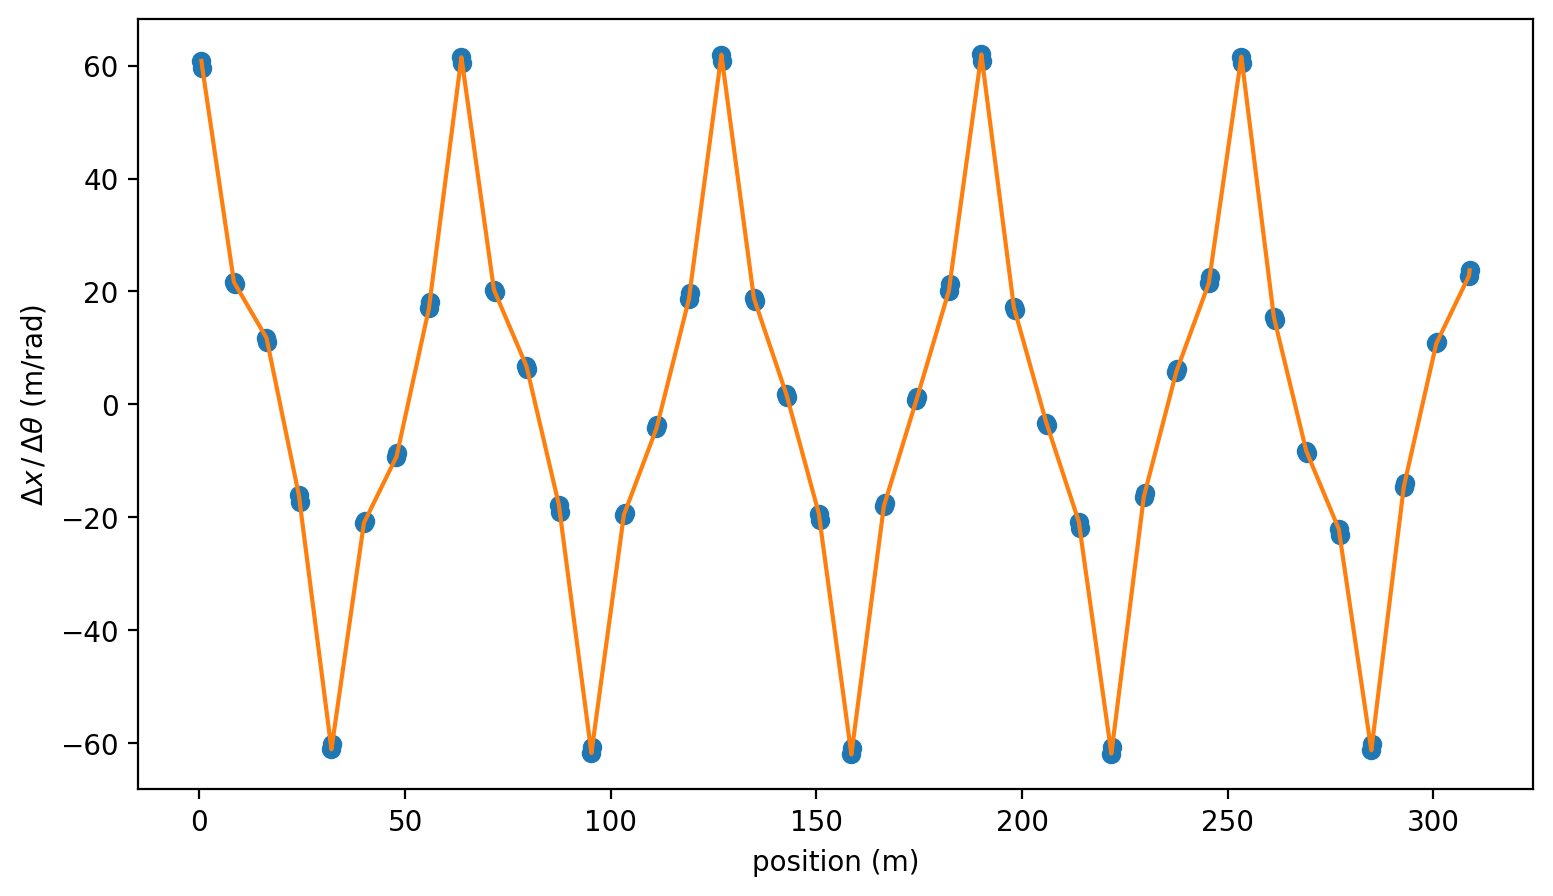

In [21]:
plt.figure(figsize=(9,5))
plt.plot(ids_bpm,orm[:,0],'o')
plt.plot(ids_bpm,orm[:,0],'-')
plt.xlabel('position (m)')
plt.ylabel(r'$\Delta x \,/\, \Delta \theta$ (m/rad)');

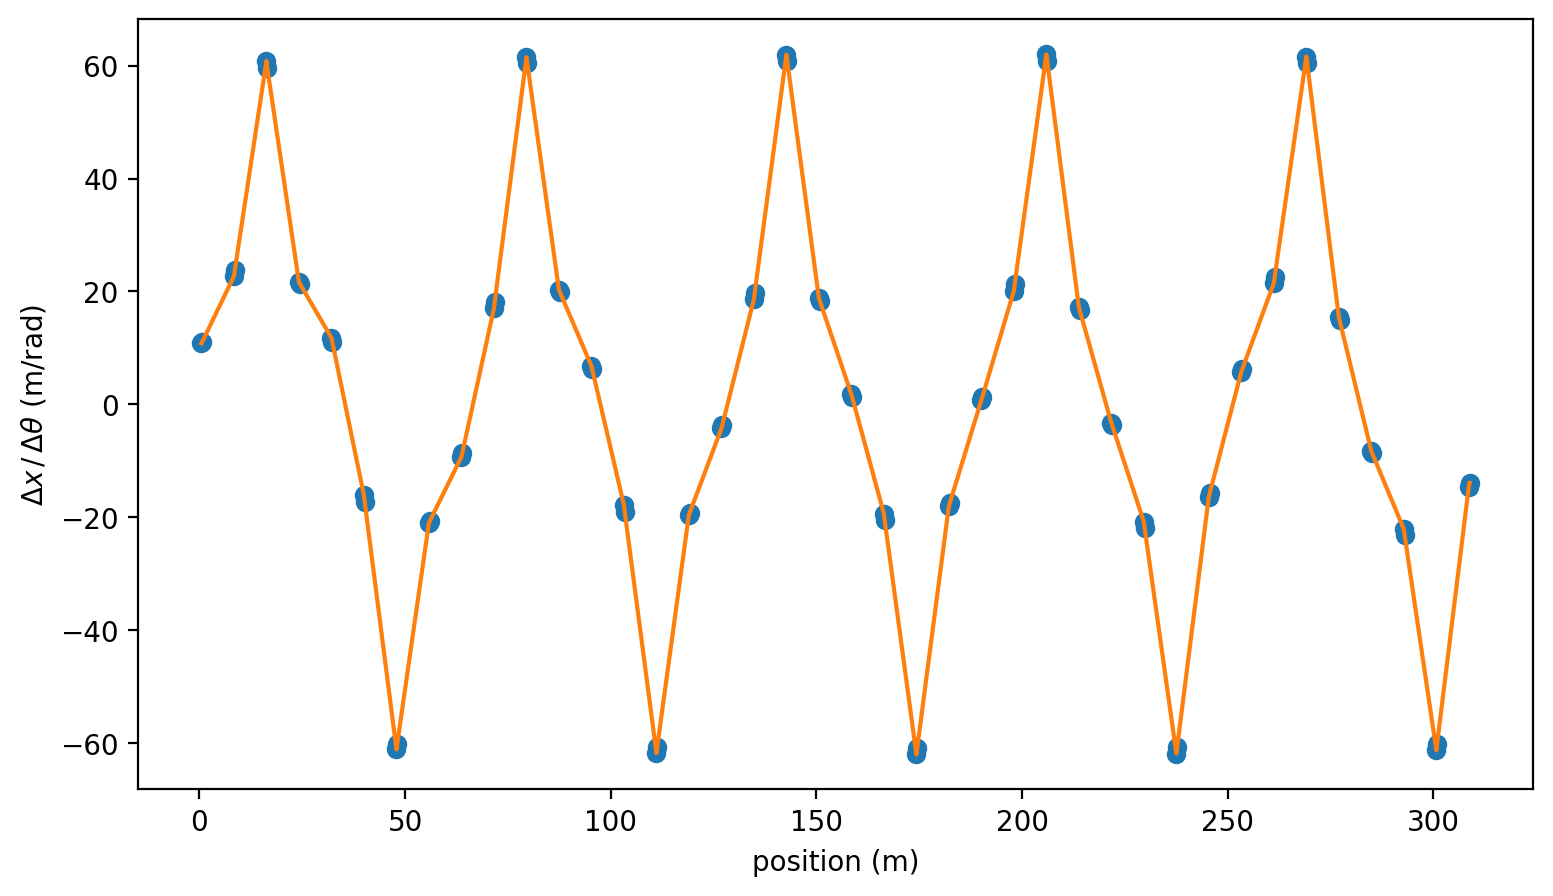

In [22]:
plt.figure(figsize=(9,5))
plt.plot(ids_bpm,orm[:,1],'o')
plt.plot(ids_bpm,orm[:,1],'-')
plt.xlabel('position (m)')
plt.ylabel(r'$\Delta x \,/\, \Delta \theta$ (m/rad)');

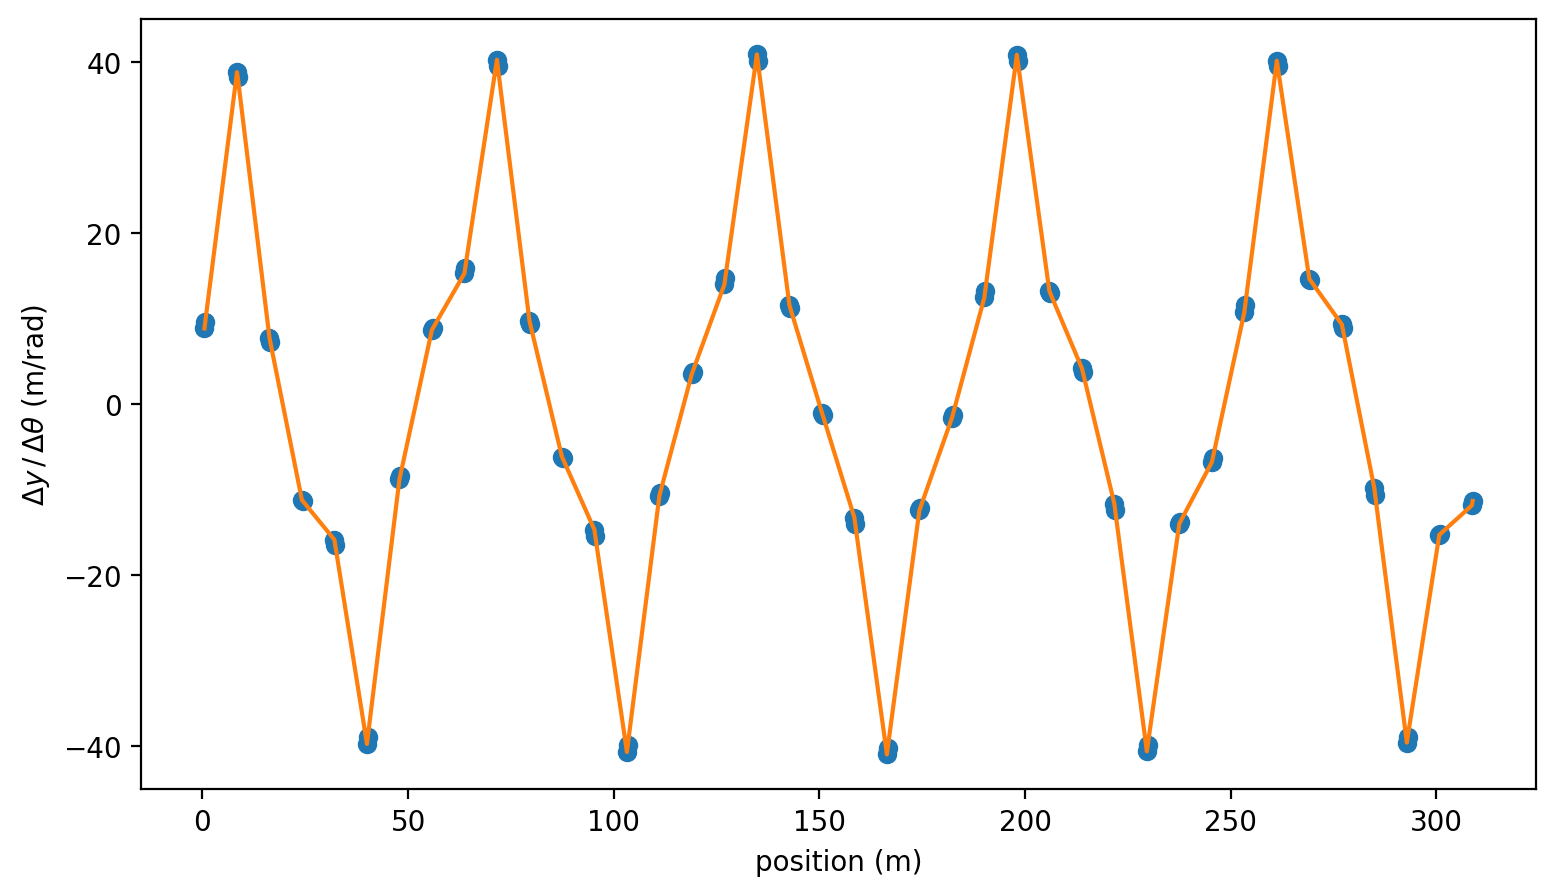

In [23]:
plt.figure(figsize=(9,5))
plt.plot(ids_bpm,orm[:,20],'o')
plt.plot(ids_bpm,orm[:,20],'-')
plt.xlabel('position (m)')
plt.ylabel(r'$\Delta y \,/\, \Delta \theta$ (m/rad)');

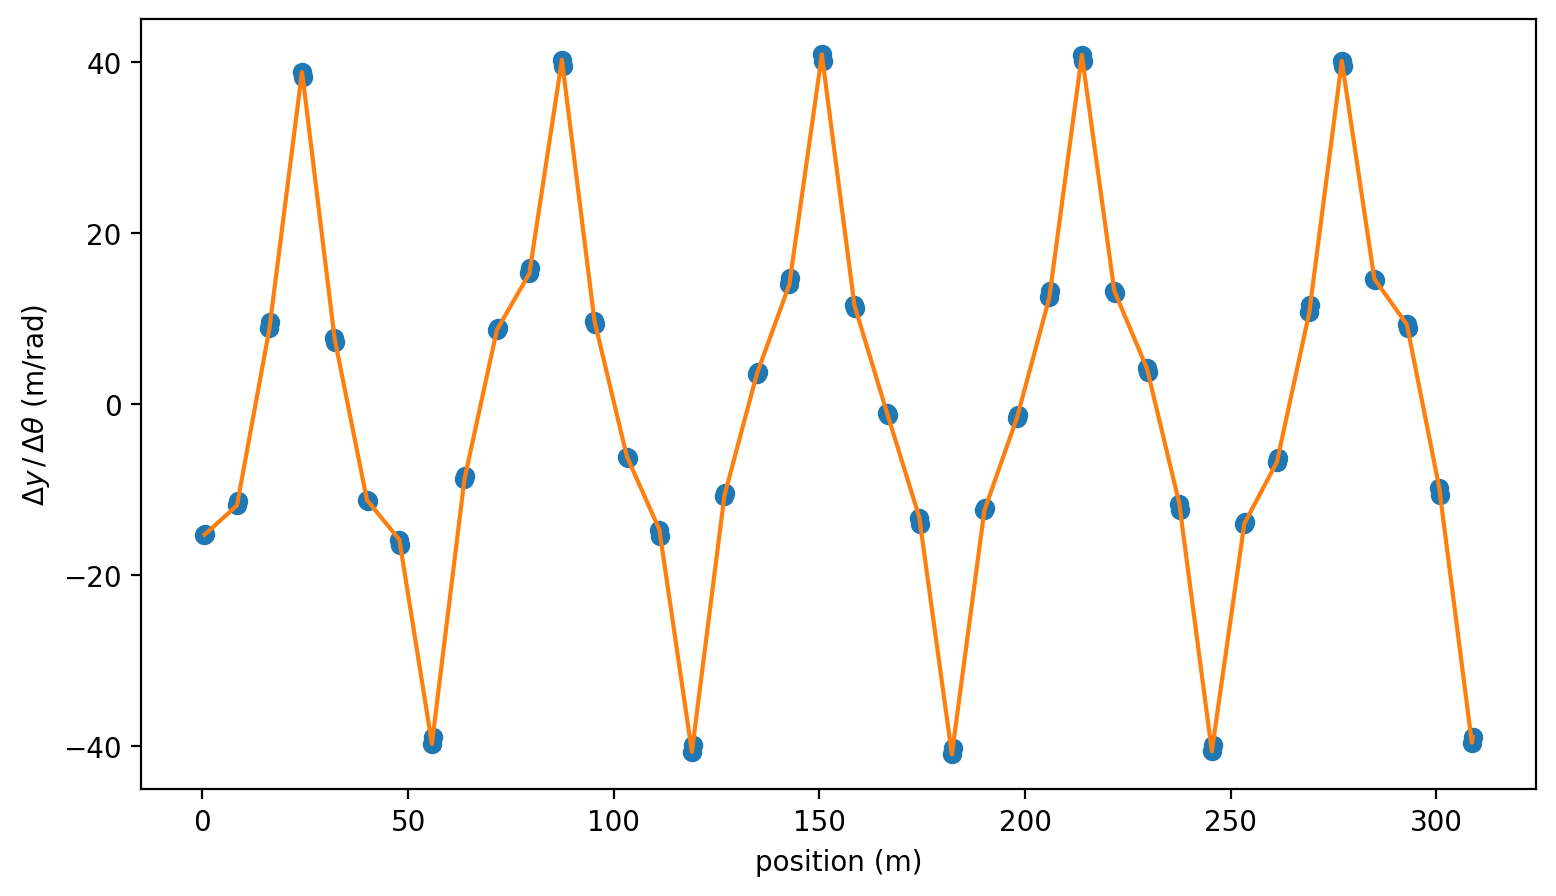

In [24]:
plt.figure(figsize=(9,5))
plt.plot(ids_bpm,orm[:,21],'o')
plt.plot(ids_bpm,orm[:,21],'-')
plt.xlabel('position (m)')
plt.ylabel(r'$\Delta y \,/\, \Delta \theta$ (m/rad)');

# Now we can compare the simple way and the normal form way to calculate ORM

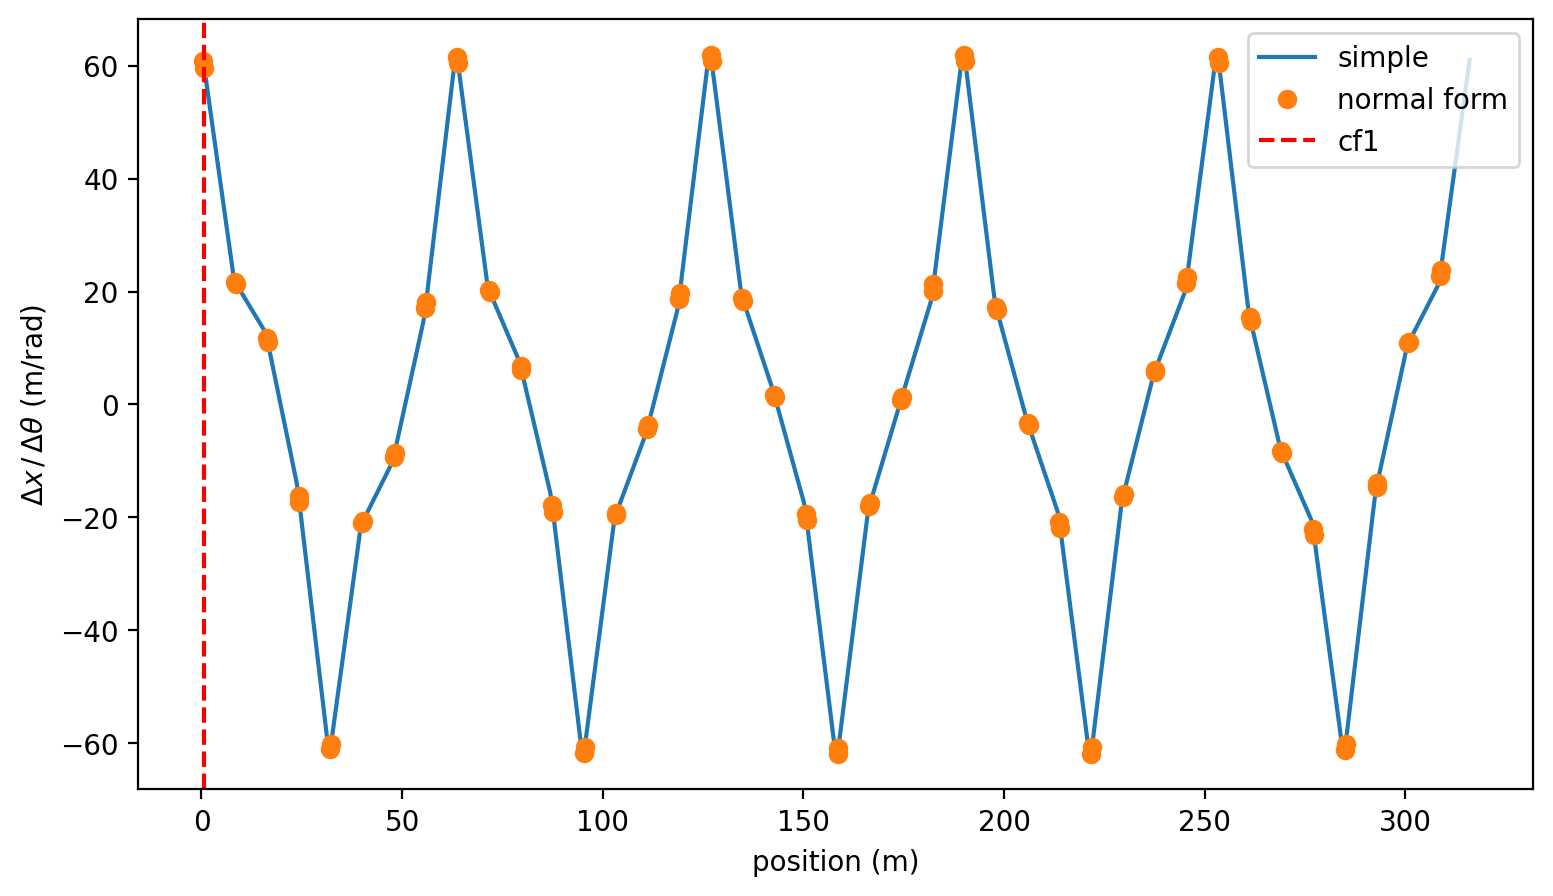

In [25]:
hkick1 = 0.0001
t_hor_pos = jl.twiss(simple_ring)

hkick1 = -0.0001
t_hor_neg = jl.twiss(simple_ring)

hor_response = (t_hor_pos.orbit_x - t_hor_neg.orbit_x).to_numpy() / 0.0002

plt.figure(figsize=(9,5))
plt.plot(t_hor_pos.s, hor_response, '-', label='simple')
plt.plot(ids_bpm,orm[:,0],'o',label='normal form')
plt.axvline(simple_ring.line[3].s,color='r',linestyle='--',label='cf1')
plt.xlabel('position (m)')
plt.ylabel(r'$\Delta x \,/\, \Delta \theta$ (m/rad)')
plt.legend();

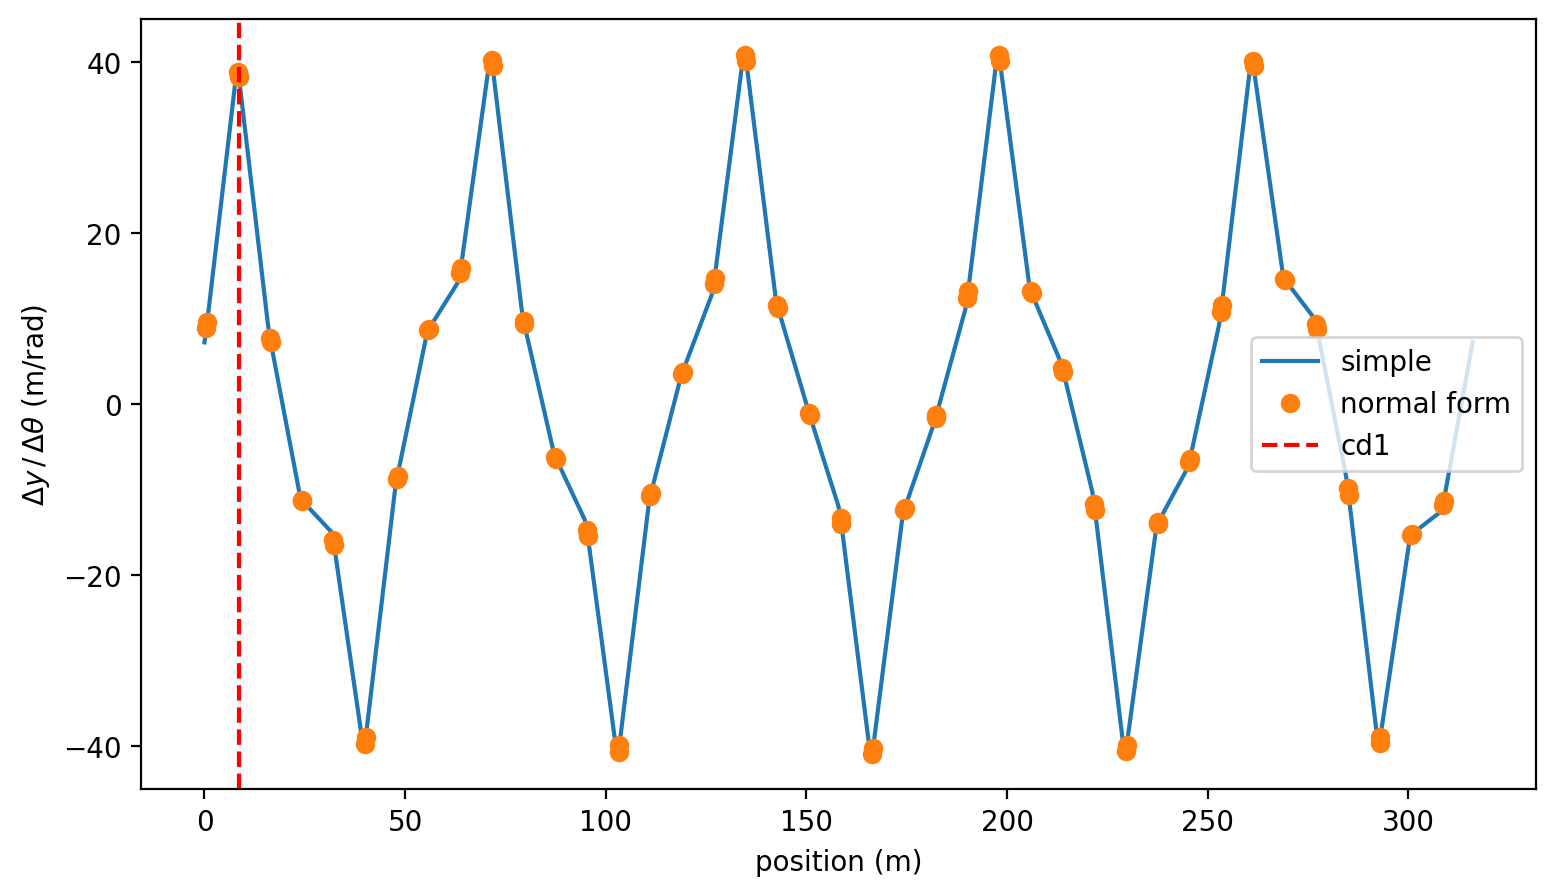

In [26]:
vkick1 = 0.0001
t_ver_pos = jl.twiss(simple_ring)

vkick1 = -0.0001
t_ver_neg = jl.twiss(simple_ring)

ver_response = (t_ver_pos.orbit_y - t_ver_neg.orbit_y).to_numpy() / 0.0002

plt.figure(figsize=(9,5))
plt.plot(t_ver_pos.s, ver_response, '-', label='simple')
plt.plot(ids_bpm,orm[:,20],'o',label='normal form')
plt.axvline(simple_ring.line[11].s,color='r',linestyle='--',label='cd1')
plt.xlabel('position (m)')
plt.ylabel(r'$\Delta y \,/\, \Delta \theta$ (m/rad)')
plt.legend();